In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
ID_COLUMN = "Row_id"
TARGET_COLUMN = "Result"

PUBLIC_DATA_PATH = Path("public_data.csv")
TRAIN_DATA_PATH = Path("train_data.csv")
TEST_DATA_PATH = Path("test_data.csv")
INPUT_PATH = Path("input.csv")
OUTPUT_PATH = Path("output.csv")

## 1. Загрузка данных


In [2]:
data = pd.read_csv(PUBLIC_DATA_PATH)
data.head()

,Row_id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,0,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,2,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,3,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,4,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


## 2. EDA — первичный анализ данных


In [3]:
print(f"Размер таблицы: {data.shape}")
print(f"Количество объектов: {data.shape[0]}")
print(f"Количество столбцов: {data.shape[1]}")
print(f"Целевой столбец: {TARGET_COLUMN}")

Размер таблицы: (9949, 32)
Количество объектов: 9949
Количество столбцов: 32
Целевой столбец: Result


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9949 entries, 0 to 9948
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Row_id                       9949 non-null   int64
 1   having_IP_Address            9949 non-null   int64
 2   URL_Length                   9949 non-null   int64
 3   Shortining_Service           9949 non-null   int64
 4   having_At_Symbol             9949 non-null   int64
 5   double_slash_redirecting     9949 non-null   int64
 6   Prefix_Suffix                9949 non-null   int64
 7   having_Sub_Domain            9949 non-null   int64
 8   SSLfinal_State               9949 non-null   int64
 9   Domain_registeration_length  9949 non-null   int64
 10  Favicon                      9949 non-null   int64
 11  port                         9949 non-null   int64
 12  HTTPS_token                  9949 non-null   int64
 13  Request_URL                  9949 non-null   int64
 14  URL

In [5]:
print(f"Количество пропусков: {data.isna().sum().sum()}")
print(f"Количество полных дубликатов: {data.duplicated().sum()}")
print(f"Уникальных Row_id: {data[ID_COLUMN].nunique()} из {len(data)}")

Количество пропусков: 0
Количество полных дубликатов: 0
Уникальных Row_id: 9949 из 9949


### Распределение целевого признака


,Количество,Доля
Result,,
-1,4415,0.443763
1,5534,0.556237


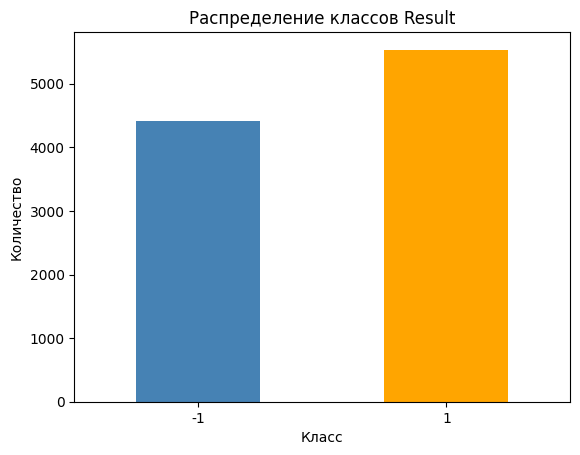

In [6]:
target_counts = data[TARGET_COLUMN].value_counts().sort_index()
target_shares = data[TARGET_COLUMN].value_counts(normalize=True).sort_index()

target_table = pd.DataFrame({"Количество": target_counts, "Доля": target_shares})
display(target_table)

target_counts.plot(kind="bar", color=["steelblue", "orange"], title="Распределение классов Result")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()

### Признаки


In [7]:
feature_columns = [column for column in data.columns if column not in {ID_COLUMN, TARGET_COLUMN}]

print(f"Количество признаков: {len(feature_columns)}")
print(feature_columns[:10])

Количество признаков: 30
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon']


In [8]:
pd.DataFrame(
    {
        "Уникальных значений": data[feature_columns].nunique(),
        "Минимум": data[feature_columns].min(),
        "Максимум": data[feature_columns].max(),
    }
).head(10)

,Уникальных значений,Минимум,Максимум
having_IP_Address,2,-1,1
URL_Length,3,-1,1
Shortining_Service,2,-1,1
having_At_Symbol,2,-1,1
double_slash_redirecting,2,-1,1
Prefix_Suffix,2,-1,1
having_Sub_Domain,3,-1,1
SSLfinal_State,3,-1,1
Domain_registeration_length,2,-1,1
Favicon,2,-1,1


### Распределение значений признаков


Значение,-1,0,1
Признак,,,
Abnormal_URL,1467,0,8482
DNSRecord,3315,0,6634
Domain_registeration_length,6665,0,3284
Favicon,1851,0,8098
Google_Index,1373,0,8576
HTTPS_token,1614,0,8335
Iframe,914,0,9035
Links_in_tags,3560,4003,2386
Links_pointing_to_page,495,5542,3912


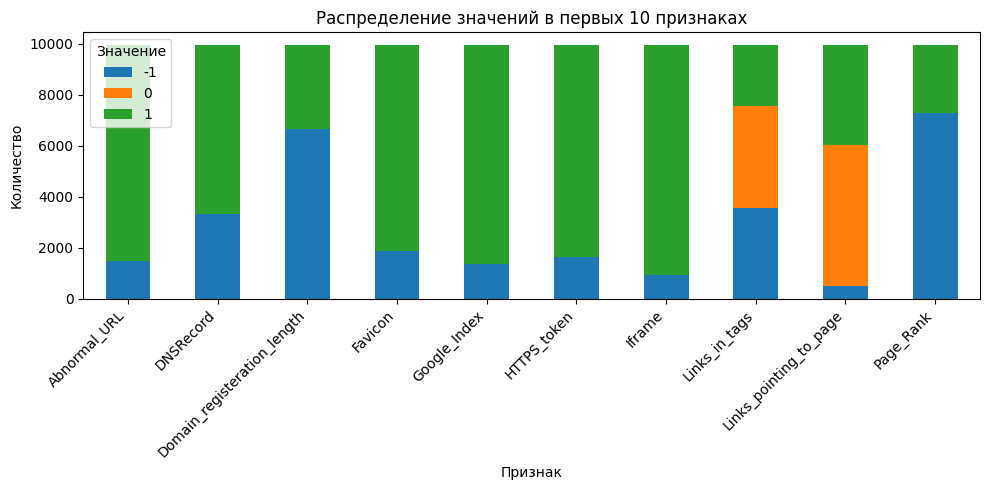

In [9]:
value_distribution = (
    data[feature_columns]
    .melt(var_name="Признак", value_name="Значение")
    .groupby(["Признак", "Значение"])
    .size()
    .unstack(fill_value=0)
)

display(value_distribution.head(10))

value_distribution.head(10).plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Распределение значений в первых 10 признаках")
plt.xlabel("Признак")
plt.ylabel("Количество")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Связь признаков с целевым столбцом


,Корреляция с Result
SSLfinal_State,0.713548
URL_of_Anchor,0.690903
web_traffic,0.412075
Prefix_Suffix,0.348886
having_Sub_Domain,0.269844
Request_URL,0.254808
Links_in_tags,0.246266
Domain_registeration_length,-0.228741
SFH,0.206515
age_of_domain,0.145105


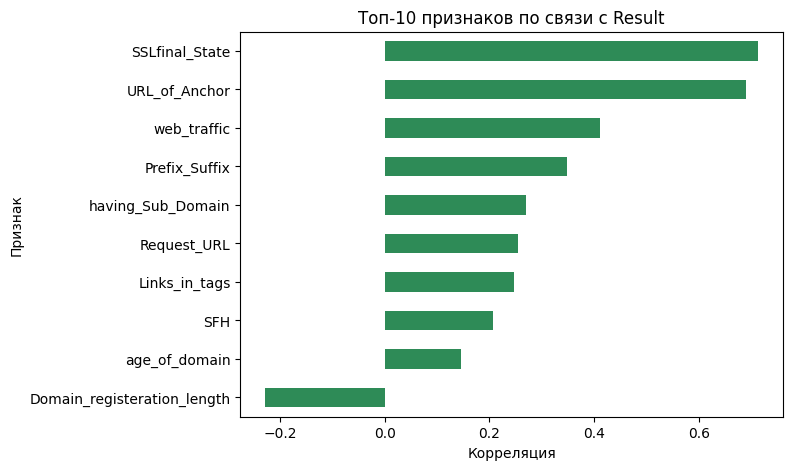

In [10]:
target_correlation = (
    data[feature_columns + [TARGET_COLUMN]]
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(target_correlation.head(10).to_frame("Корреляция с Result"))

target_correlation.head(10).sort_values().plot(kind="barh", figsize=(7, 5), color="seagreen")
plt.title("Топ-10 признаков по связи с Result")
plt.xlabel("Корреляция")
plt.ylabel("Признак")
plt.show()

## 3. Деление на обучающую и тестовую выборки


train_data.csv: (7461, 32)
test_data.csv: (2488, 32)


,train,test
Result,,
-1,3311,1104
1,4150,1384


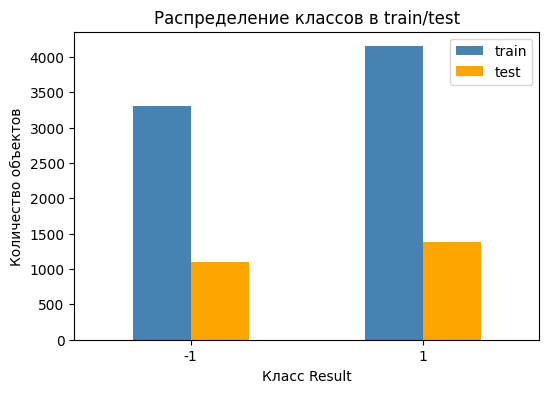

In [11]:
train_data, test_data = train_test_split(
    data,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=data[TARGET_COLUMN],
)

train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

train_data.to_csv(TRAIN_DATA_PATH, index=False)
test_data.to_csv(TEST_DATA_PATH, index=False)

print(f"train_data.csv: {train_data.shape}")
print(f"test_data.csv: {test_data.shape}")

split_balance = pd.DataFrame(
    {
        "train": train_data[TARGET_COLUMN].value_counts().sort_index(),
        "test": test_data[TARGET_COLUMN].value_counts().sort_index(),
    }
)

display(split_balance)

split_balance.plot(kind="bar", figsize=(6, 4), color=["steelblue", "orange"])
plt.title("Распределение классов в train/test")
plt.xlabel("Класс Result")
plt.ylabel("Количество объектов")
plt.xticks(rotation=0)
plt.show()

In [12]:
X_train = train_data[feature_columns]
y_train = train_data[TARGET_COLUMN]

X_test = test_data[feature_columns]
y_test = test_data[TARGET_COLUMN]

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (7461, 30)
X_test: (2488, 30)


## 4. Сравнение моделей



Обучаем модель: DecisionTree


Обучаем модель: RandomForest


,Модель,Accuracy на тестовой выборке,CV accuracy mean,CV accuracy std
0,RandomForest,0.974678,NaN,NaN
1,DecisionTree,0.967846,0.952822,0.006693


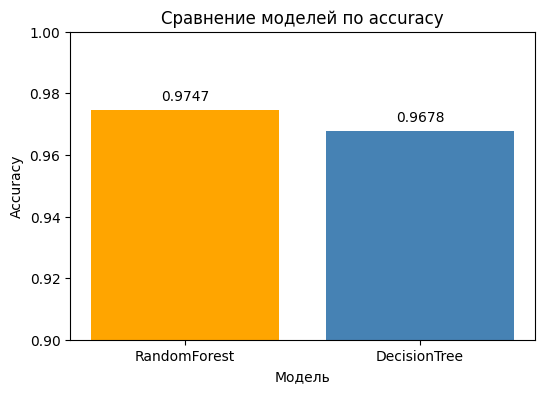

DecisionTree CV accuracy: 0.95282 ± 0.00669
Для RandomForest кросс-валидация не применялась
Выбранная модель: RandomForest


In [ ]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

model_results = []

dt_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
dt_cv_scores = cross_val_score(
    models["DecisionTree"],
    X_train,
    y_train,
    cv=dt_cv,
    scoring="accuracy",
)

for name, model in models.items():
    print(f"Обучаем модель: {name}")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    row = {
        "Модель": name,
        "Accuracy на тестовой выборке": accuracy,
        "CV accuracy mean": None,
        "CV accuracy std": None,
    }

    if name == "DecisionTree":
        row["CV accuracy mean"] = dt_cv_scores.mean()
        row["CV accuracy std"] = dt_cv_scores.std()

    model_results.append(row)

model_results = pd.DataFrame(model_results).sort_values(
    "Accuracy на тестовой выборке",
    ascending=False,
).reset_index(drop=True)

display(model_results)


best_model_name = model_results.loc[0, "Модель"]

## 5. Проверка выбранной модели


In [14]:
best_model = clone(models[best_model_name])
best_model.fit(X_train, y_train)

test_predictions = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Выбранная модель: {best_model_name}")
print(f"Accuracy на тестовой выборке: {test_accuracy:.5f}")
print()
print(classification_report(y_test, test_predictions, digits=4))

Выбранная модель: RandomForest
Accuracy на тестовой выборке: 0.97468

              precision    recall  f1-score   support

          -1     0.9780    0.9647    0.9713      1104
           1     0.9721    0.9827    0.9774      1384

    accuracy                         0.9747      2488
   macro avg     0.9750    0.9737    0.9743      2488
weighted avg     0.9747    0.9747    0.9747      2488



,Предсказанный -1,Предсказанный 1
Истинный -1,1065,39
Истинный 1,24,1360


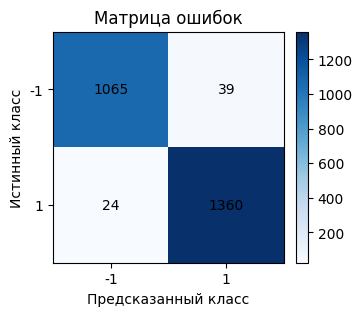

In [15]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, test_predictions, labels=labels)
cm_df = pd.DataFrame(
    cm,
    index=[f"Истинный {label}" for label in labels],
    columns=[f"Предсказанный {label}" for label in labels],
)

display(cm_df)

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Матрица ошибок")
ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

### Важность признаков



,Признак,Важность
7,SSLfinal_State,0.312176
13,URL_of_Anchor,0.248573
25,web_traffic,0.089453
6,having_Sub_Domain,0.057515
14,Links_in_tags,0.042390
5,Prefix_Suffix,0.041564
12,Request_URL,0.020074
28,Links_pointing_to_page,0.019887
8,Domain_registeration_length,0.018459
15,SFH,0.017515


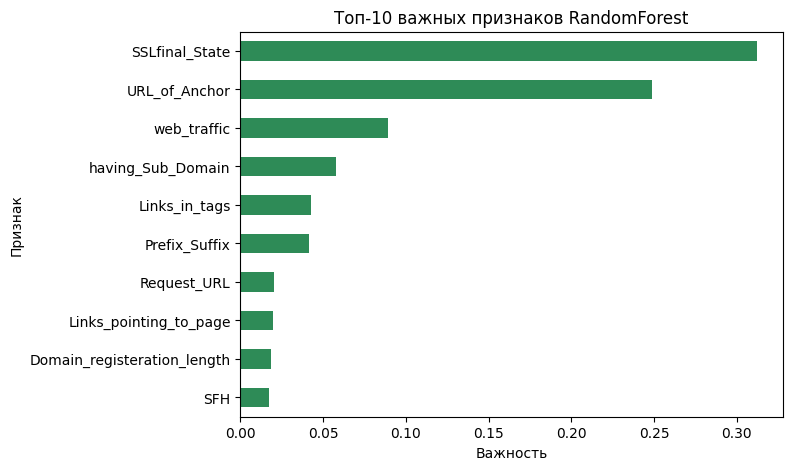

In [16]:
if best_model_name == "RandomForest":
    importance = pd.DataFrame(
        {
            "Признак": feature_columns,
            "Важность": best_model.feature_importances_,
        }
    ).sort_values("Важность", ascending=False).head(10)

    display(importance)

    importance.sort_values("Важность").plot(
        kind="barh",
        x="Признак",
        y="Важность",
        figsize=(7, 5),
        legend=False,
        color="seagreen",
    )
    plt.title("Топ-10 важных признаков RandomForest")
    plt.xlabel("Важность")
    plt.ylabel("Признак")
    plt.show()
else:
    print("Важность признаков выводится только для RandomForest.")

## 6. Создание `input.csv` и `output.csv`


In [17]:
if not INPUT_PATH.exists():
    data[[ID_COLUMN, *feature_columns]].to_csv(INPUT_PATH, index=False)
    print(f"Создан файл: {INPUT_PATH}")
else:
    print(f"Файл уже существует: {INPUT_PATH}")

X_all = data[feature_columns]
y_all = data[TARGET_COLUMN]

final_model = clone(models[best_model_name])
final_model.fit(X_all, y_all)

input_data = pd.read_csv(INPUT_PATH)
output_data = input_data.copy()
output_data[TARGET_COLUMN] = final_model.predict(input_data[feature_columns])
output_data.to_csv(OUTPUT_PATH, index=False)

print(f"Создан файл: {OUTPUT_PATH}")
output_data.head()

Файл уже существует: input.csv


Создан файл: output.csv


,Row_id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,0,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,2,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,3,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,4,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


## 7. Итоговый результат

In [18]:
summary = pd.DataFrame(
    [
        {
            "Итоговая модель": best_model_name,
            "Accuracy на тесте": test_accuracy,
            "Строк в train": len(train_data),
            "Строк в test": len(test_data),
            "Файл результата": str(OUTPUT_PATH),
        }
    ]
)

display(summary)

print(f"Итоговая модель: {best_model_name}")
print(f"Итоговое качество accuracy: {test_accuracy:.5f}")

,Итоговая модель,Accuracy на тесте,Строк в train,Строк в test,Файл результата
0,RandomForest,0.974678,7461,2488,output.csv


Итоговая модель: RandomForest
Итоговое качество accuracy: 0.97468
